# 01_Pipeline_Inferencia_16-CLASES_Codespaces

Pipeline de Inferencia en Streaming para 16-CLASES(Producción).
Extracción -> Limpieza Estática -> Predicción al Vuelo.

In [34]:
# ==========================================
# PIPELINE DE INFERENCIA EN STREAMING (PRODUCCIÓN)
# Extracción -> Limpieza Estática -> Predicción
# ==========================================
import os
import sys
print(sys.executable)
import subprocess
import time
import pandas as pd
import numpy as np
from pathlib import Path
#import joblib  # Para cargar el modelo ya entrenado

import catboost
import lightgbm
import xgboost



# --- 1. CONFIGURACIÓN DE RUTAS ---
BASE_DIR = Path("/workspaces/CICFlowMeter-Pipeline_ProyectoAplicado_UNAD_ECDyA")
PCAP_PATH = BASE_DIR / "DoS-TCP_Flood10.pcap"
TMP_DIR = BASE_DIR / ".tmp_cicflowmeter"
RESULTS_FILE = BASE_DIR / "outputs" / "models"/ "predicciones_finales.csv"
MODEL_PATH = BASE_DIR / "outputs" / "models" / "CatBoostClassifier_02.pkl" 

TMP_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_FILE.parent.mkdir(parents=True, exist_ok=True)
if RESULTS_FILE.exists(): RESULTS_FILE.unlink()

print(f"✅ CatBoost: {catboost.__version__}")
print(f"✅ LightGBM: {lightgbm.__version__}")
print(f"✅ XGBoost: {xgboost.__version__}")

print(f"✅ NumPy version: {np.__version__}")
print(f"✅ ¿Tiene _core? {hasattr(np, '_core')}")


/usr/local/bin/python
✅ CatBoost: 1.2.10
✅ LightGBM: 4.6.0
✅ XGBoost: 2.1.4
✅ NumPy version: 2.2.6
✅ ¿Tiene _core? True


In [3]:
# --- 2. MAPEO Y ORDEN ESTRICTO DEL MODELO ---
MAPEO = {
    'src_port':'Src Port', 'dst_port':'Dst Port', 'protocol':'Protocol',
    'flow_duration':'Flow Duration', 'tot_fwd_pkts':'Total Fwd Packet',
    'tot_bwd_pkts':'Total Bwd packets', 'totlen_fwd_pkts':'Total Length of Fwd Packet',
    'totlen_bwd_pkts':'Total Length of Bwd Packet', 'fwd_pkt_len_max':'Fwd Packet Length Max',
    'fwd_pkt_len_min':'Fwd Packet Length Min', 'fwd_pkt_len_std':'Fwd Packet Length Std',
    'bwd_pkt_len_min':'Bwd Packet Length Min', 'flow_byts_s':'Flow Bytes/s',
    'flow_pkts_s':'Flow Packets/s', 'flow_iat_mean':'Flow IAT Mean',
    'flow_iat_min':'Flow IAT Min', 'fwd_iat_tot':'Fwd IAT Total',
    'fwd_iat_min':'Fwd IAT Min', 'bwd_iat_tot':'Bwd IAT Total',
    'fwd_psh_flags':'Fwd PSH Flags', 'fwd_header_len':'Fwd Header Length',
    'bwd_pkts_s':'Bwd Packets/s', 'pkt_len_std':'Packet Length Std',
    'fin_flag_cnt':'FIN Flag Count', 'syn_flag_cnt':'SYN Flag Count',
    'rst_flag_cnt':'RST Flag Count', 'ack_flag_cnt':'ACK Flag Count',
    'urg_flag_cnt':'URG Flag Count', 'cwe_flag_count':'CWR Flag Count',
    'down_up_ratio':'Down/Up Ratio', 'fwd_byts_b_avg':'Fwd Bytes/Bulk Avg',
    'bwd_byts_b_avg':'Bwd Bytes/Bulk Avg', 'subflow_fwd_pkts':'Subflow Fwd Packets',
    'subflow_fwd_byts':'Subflow Fwd Bytes', 'subflow_bwd_pkts':'Subflow Bwd Packets',
    'init_fwd_win_byts':'FWD Init Win Bytes', 'init_bwd_win_byts':'Bwd Init Win Bytes',
    'fwd_act_data_pkts':'Fwd Act Data Pkts', 'active_mean':'Active Mean',
    'idle_std':'Idle Std'
}

# ORDEN EXACTO E INAMOVIBLE DEL MODELO
COLS_40 = [
    "Src Port", "Dst Port", "Protocol", "Flow Duration", "Total Fwd Packet", 
    "Total Bwd packets", "Total Length of Fwd Packet", "Total Length of Bwd Packet", 
    "Fwd Packet Length Max", "Fwd Packet Length Min", "Fwd Packet Length Std", 
    "Bwd Packet Length Min", "Flow Bytes/s", "Flow Packets/s", "Flow IAT Mean", 
    "Flow IAT Min", "Fwd IAT Total", "Fwd IAT Min", "Bwd IAT Total", "Fwd PSH Flags", 
    "Fwd Header Length", "Bwd Packets/s", "Packet Length Std", "FIN Flag Count", 
    "SYN Flag Count", "RST Flag Count", "ACK Flag Count", "URG Flag Count", 
    "CWR Flag Count", "Down/Up Ratio", "Fwd Bytes/Bulk Avg", "Bwd Bytes/Bulk Avg", 
    "Subflow Fwd Packets", "Subflow Fwd Bytes", "Subflow Bwd Packets", "FWD Init Win Bytes", 
    "Bwd Init Win Bytes", "Fwd Act Data Pkts", "Active Mean", "Idle Std"
]

# Definición para casteo seguro (memoria) sin alterar el orden del dataframe
COLS_INT32 = [
    "Src Port", "Dst Port", "Protocol", "Total Fwd Packet", "Total Bwd packets",
    "Fwd PSH Flags", "FIN Flag Count", "SYN Flag Count", "RST Flag Count",
    "ACK Flag Count", "URG Flag Count", "CWR Flag Count", 
    "Subflow Fwd Packets", "Subflow Bwd Packets", "Fwd Act Data Pkts"
]



In [31]:
# --- 3. CARGA DEL MODELO ---

import pickle

# --- CARGAR MODELO CON PICKLE ---
MODEL_PATH = "/workspaces/CICFlowMeter-Pipeline_ProyectoAplicado_UNAD_ECDyA/outputs/models/CatBoostClassifier_02.pkl"

#print(f"Cargando modelo desde {MODEL_PATH.name}...")

try:
    with open(MODEL_PATH, 'rb') as f:  # ← Sin comillas
        modelo = pickle.load(f)
    print("✅ Modelo CatBoostClassifier_02 16-Clases Cargado con pickle")
except Exception as e:
    print(f"❌ Error al cargar: {e}")



✅ Modelo CatBoostClassifier_02 16-Clases Cargado con pickle


In [11]:
import os
from pathlib import Path
import joblib

MODEL_PATH = "/workspaces/CICFlowMeter-Pipeline_ProyectoAplicado_UNAD_ECDyA/outputs/models/CatBoostClassifier_02.pkl"





# 3. Verificar los primeros bytes
print("\n🔍 Verificando cabecera del archivo:")
with open(MODEL_PATH, 'rb') as f:
    cabecera = f.read(20)
    print(f"   Hex: {cabecera.hex()}")
    print(f"   ASCII: {cabecera}")

# 4. Verificar los últimos bytes
print("\n🔍 Verificando final del archivo:")
with open(MODEL_PATH, 'rb') as f:
    f.seek(-20, os.SEEK_END)
    final = f.read(20)
    print(f"   Hex: {final.hex()}")
    print(f"   ASCII: {final}")




🔍 Verificando cabecera del archivo:
   Hex: 80059591010000000000008c0d636174626f6f73
   ASCII: b'\x80\x05\x95\x91\x01\x00\x00\x00\x00\x00\x00\x8c\rcatboos'

🔍 Verificando final del archivo:
   Hex: 294308eee09d04e697da3f94869452946575622e
   ASCII: b')C\x08\xee\xe0\x9d\x04\xe6\x97\xda?\x94\x86\x94R\x94eub.'


In [30]:
# --- RECARGAR MODELO DESDE GITHUB ---
import requests
from pathlib import Path
import joblib

MODEL_PATH = Path("/workspaces/CICFlowMeter-Pipeline_ProyectoAplicado_UNAD_ECDyA/outputs/models/CatBoostClassifier_02.pkl")

# 1. Eliminar el archivo corrupto si existe
if MODEL_PATH.exists():
    print(" Eliminando archivo corrupto...")
    MODEL_PATH.unlink()

# 2. Descargar el archivo correcto
url = "https://github.com/jandresportilla/CICFlowMeter-Pipeline_ProyectoAplicado_UNAD_ECDyA/raw/master/CatBoostClassifier_02.pkl"
print(f" Descargando modelo desde: {url}")

response = requests.get(url, stream=True)
if response.status_code == 200:
    MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
    
    # 3. Guardar el archivo
    with open(MODEL_PATH, 'wb') as f:
        total_size = 0
        for chunk in response.iter_content(chunk_size=8192):
            f.write(chunk)
            total_size += len(chunk)
    
    print(f"✅ Modelo descargado: {total_size / 1024 / 1024:.2f} MB")
    
    # 4. Verificar la integridad
    print("🔍 Verificando integridad del archivo descargado...")
    try:
        modelo = joblib.load(MODEL_PATH)
        print("✅ Modelo cargado exitosamente")
        print(f" Tipo: {type(modelo)}")
        if hasattr(modelo, 'feature_names_'):
            print(f" Características: {len(modelo.feature_names_)}")
    except Exception as e:
        print(f"❌ Error al cargar el modelo descargado: {e}")
else:
    print(f"❌ Error al descargar. Código: {response.status_code}")

 Eliminando archivo corrupto...
 Descargando modelo desde: https://github.com/jandresportilla/CICFlowMeter-Pipeline_ProyectoAplicado_UNAD_ECDyA/raw/master/CatBoostClassifier_02.pkl
✅ Modelo descargado: 59.54 MB
🔍 Verificando integridad del archivo descargado...
❌ Error al cargar el modelo descargado: No module named 'numpy._core'


In [37]:
# --- 4. FRAGMENTACIÓN DEL PCAP ---
print(f"\n--- Iniciando segmentación de {PCAP_PATH.name} ---")
for f in TMP_DIR.glob("split_chunk_*"): f.unlink()

split_cmd = ["tcpdump", "-r", str(PCAP_PATH), "-C", "20", "-w", str(TMP_DIR / "split_chunk_")]
subprocess.run(split_cmd, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
chunks = sorted(list(TMP_DIR.glob("split_chunk_*")))

t_global = time.time()
filas_totales = 0




--- Iniciando segmentación de DoS-TCP_Flood10.pcap ---


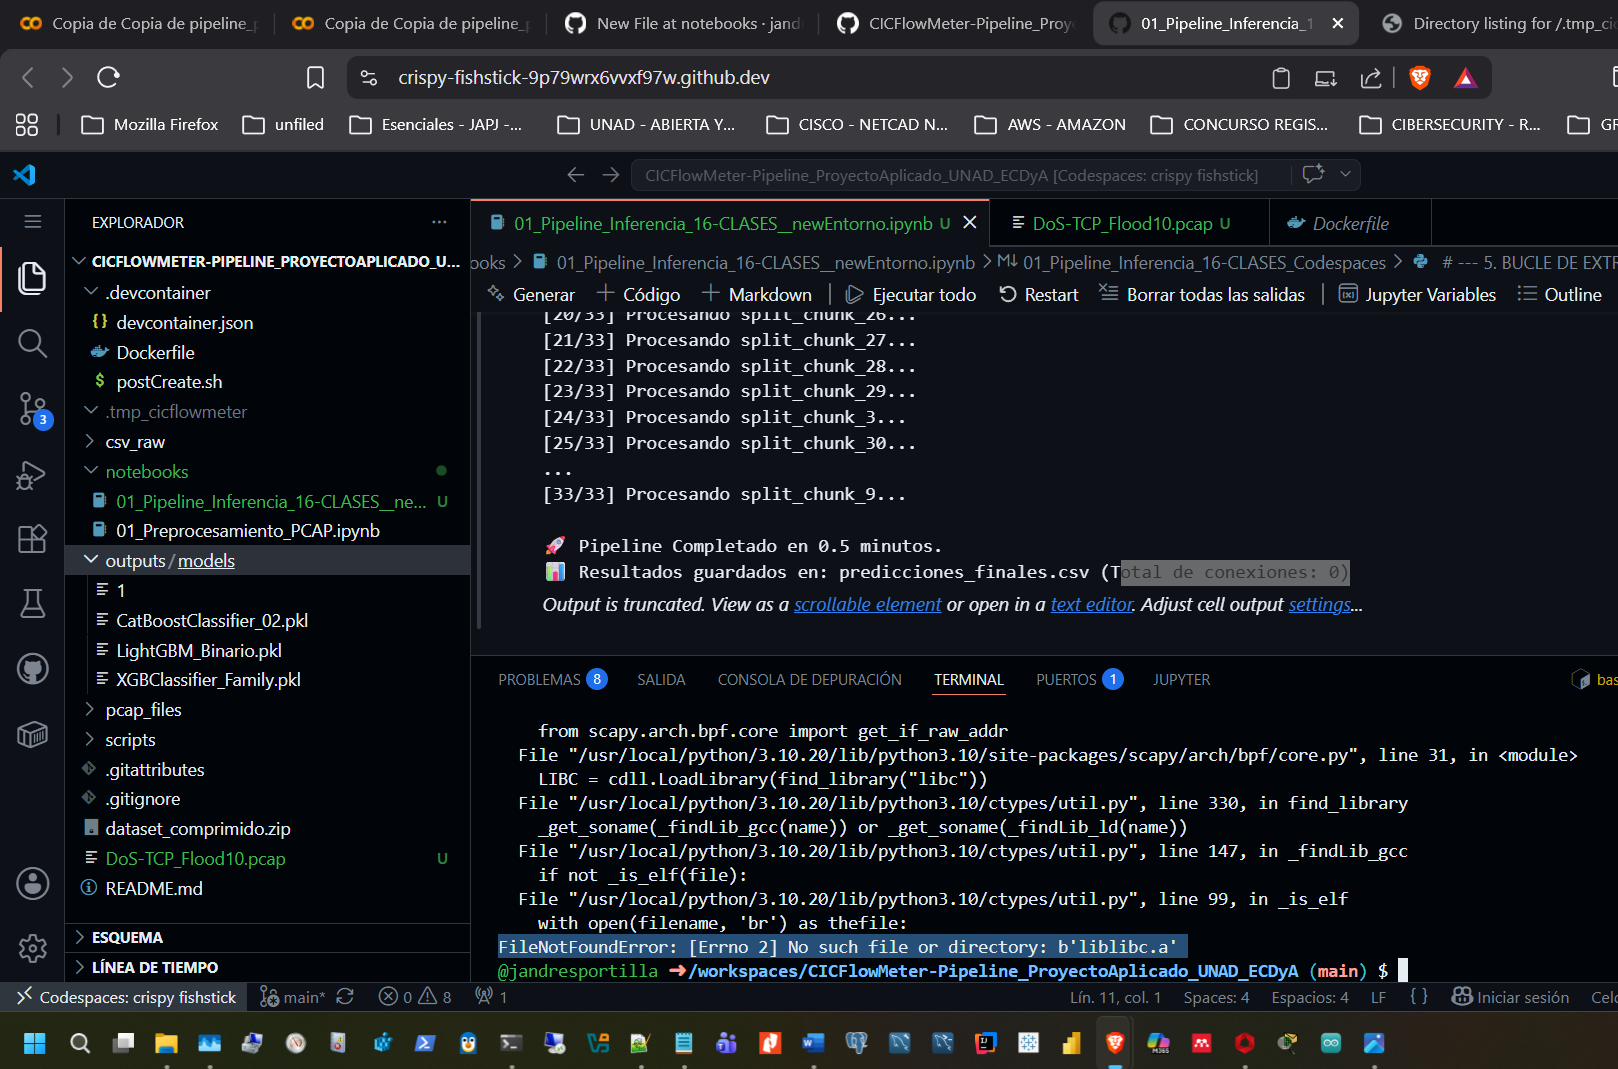

In [ ]:
# --- 5. BUCLE DE EXTRACCIÓN Y PREDICCIÓN AL VUELO ---
for idx, chunk in enumerate(chunks):
    t_chunk = time.time()
    chunk_csv = chunk.with_suffix(".csv")
    print(f"[{idx+1}/{len(chunks)}] Procesando {chunk.name}...")
    
    subprocess.run(["cicflowmeter", "-f", str(chunk), "-c", str(chunk_csv)], capture_output=True)
    
    if chunk_csv.exists() and chunk_csv.stat().st_size > 100:
        try:
            df_tmp = pd.read_csv(chunk_csv, low_memory=False)
            df_tmp.columns = df_tmp.columns.str.strip()
            
            df_renamed = pd.DataFrame()
            for k, v in MAPEO.items():
                if k in df_tmp.columns: df_renamed[v] = df_tmp[k].values
                
            # Rellenar faltantes si es necesario
            for col in COLS_40:
                if col not in df_renamed.columns:
                    df_renamed[col] = 0
                    
            # SE APLICA EL ORDEN ESTRICTO EXACTO
            df_opt = df_renamed[COLS_40].copy()
            
            # Limpieza Estática
            df_opt.replace([np.inf, -np.inf, "inf", "-inf", "Infinity", "-Infinity"], np.nan, inplace=True)
            df_opt.dropna(subset=["Flow Bytes/s", "Flow Packets/s"], inplace=True)
            
            if df_opt.empty:
                continue
                
            # Casteo Estricto de memoria (Se asegura el tipo por columna, sin mover su posición)
            for col in COLS_40:
                if col in COLS_INT32:
                    df_opt[col] = pd.to_numeric(df_opt[col], errors='coerce').fillna(0).astype(np.int32)
                else:
                    df_opt[col] = pd.to_numeric(df_opt[col], errors='coerce').fillna(0.0).astype(np.float32)


            # --- INFERENCIA GARANTIZADA EN ORDEN EXACTO ---
            # El dataframe df_opt entra al modelo exactamente en el orden COLS_40
            predicciones = modelo.predict(df_opt)
            df_opt['Prediccion_Modelo'] = predicciones
            
            # (Simulación visual mientras enlazas el modelo)
            #df_opt['Prediccion_Modelo'] = "Pendiente_Prediccion" 
            
            header = not RESULTS_FILE.exists()
            df_opt.to_csv(RESULTS_FILE, mode='a', index=False, header=header)
            
            filas_totales += len(df_opt)
            print(f"   ✅ OK: {len(df_opt)} flujos listos/clasificados. Tiempo: {time.time() - t_chunk:.1f}s")
            
        except Exception as e:
            print(f"   ❌ Error en {chunk_csv.name}: {e}")
            
    # Limpieza inmediata
    chunk.unlink()
    if chunk_csv.exists(): chunk_csv.unlink()

print(f"\n🚀 Pipeline Completado en {(time.time() - t_global) / 60:.1f} minutos.")
print(f"📊 Resultados guardados en: {RESULTS_FILE.name} (Total de conexiones: {filas_totales})")

[1/33] Procesando split_chunk_...
[2/33] Procesando split_chunk_1...
[3/33] Procesando split_chunk_10...
[4/33] Procesando split_chunk_11...
[5/33] Procesando split_chunk_12...
[6/33] Procesando split_chunk_13...
[7/33] Procesando split_chunk_14...
[8/33] Procesando split_chunk_15...
[9/33] Procesando split_chunk_16...
[10/33] Procesando split_chunk_17...
[11/33] Procesando split_chunk_18...
[12/33] Procesando split_chunk_19...
[13/33] Procesando split_chunk_2...
[14/33] Procesando split_chunk_20...
[15/33] Procesando split_chunk_21...
[16/33] Procesando split_chunk_22...
[17/33] Procesando split_chunk_23...
[18/33] Procesando split_chunk_24...
[19/33] Procesando split_chunk_25...
[20/33] Procesando split_chunk_26...
